In [28]:
!pip install kaleido==0.2.1

In [29]:
import pandas as pd
import plotly.express as px
import plotly
print(plotly.__version__)
import kaleido
import seaborn as sns
import plotly.io as pio
import numpy as np
from datetime import  date, timedelta
import matplotlib.pyplot as plt
pio.renderers.default='plotly_mimetype+notebook'
import warnings
warnings.filterwarnings('ignore')

5.24.1


In [30]:
df_logs=pd.read_csv(r'/kaggle/input/music-1/music_logs_with_churn.csv', parse_dates=['timestamp']).drop('is_morning', axis=1)
df_logs.info()
display(df_logs.isna().sum())
df_logs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87278 entries, 0 to 87277
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             87278 non-null  int64         
 1   track_id            87278 non-null  int64         
 2   timestamp           87278 non-null  datetime64[ns]
 3   hour                87278 non-null  int64         
 4   track_genre         87278 non-null  object        
 5   track_duration_sec  87278 non-null  int64         
 6   action              87278 non-null  object        
 7   listen_time_sec     87278 non-null  int64         
 8   model_confidence    87278 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(2)
memory usage: 6.0+ MB


user_id               0
track_id              0
timestamp             0
hour                  0
track_genre           0
track_duration_sec    0
action                0
listen_time_sec       0
model_confidence      0
dtype: int64

,user_id,track_id,timestamp,hour,track_genre,track_duration_sec,action,listen_time_sec,model_confidence
0,4117,1229,2025-01-01 00:03:23,0,rock,118,skip,45,0.324460
1,1448,1938,2025-01-01 00:04:14,0,electronic,256,listen,252,0.602017
2,4917,2163,2025-01-01 00:07:50,0,pop,199,skip,23,0.678229
3,1860,2361,2025-01-01 00:07:54,0,pop,121,listen,121,0.665973
4,1292,1470,2025-01-01 00:08:02,0,rock,136,skip,60,0.452052


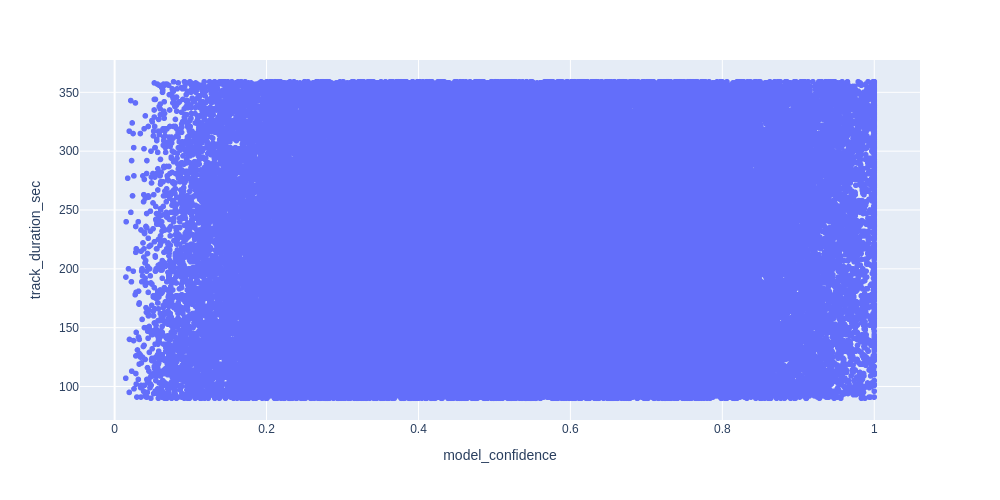

In [31]:
fig=px.scatter(df_logs, x='model_confidence',y='track_duration_sec',width=1000)
fig.show('png')

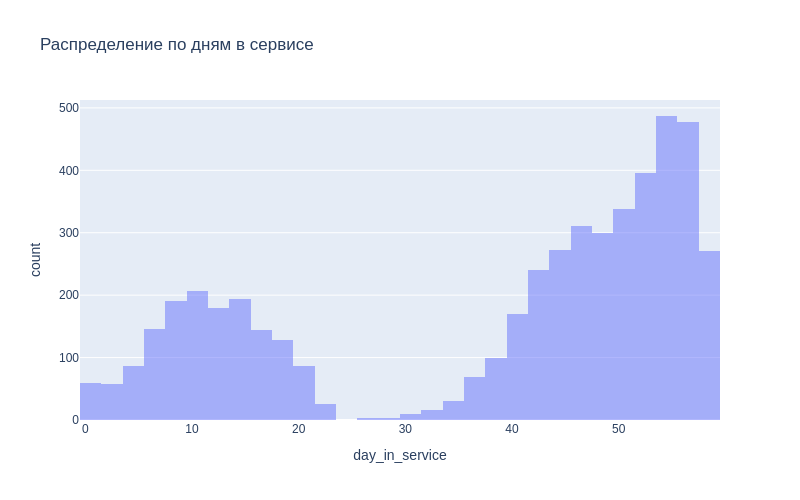

In [ ]:
# вычисляем дни нахождения в сервисе по юзерно
df_prodolzit=df_logs.groupby('user_id', as_index=False).agg(ts_min=('timestamp', lambda x: x.min()), ts_max=('timestamp', lambda x: x.max()))
df_prodolzit['day_in_service']=(pd.to_datetime(df_prodolzit['ts_max'])-pd.to_datetime(df_prodolzit['ts_min'])).dt.days
h=500
w=800
fig_prod=px.histogram(df_prodolzit,x='day_in_service', barmode='overlay', height=h, width=w, title='Распределение по дням в сервисе' )
fig_prod.show('png')


+ _видим четкое разделение юзеров на два сегмента по дням в сервисе_

In [33]:
### считаем отток
t_cut=(df_logs['timestamp'].max()-timedelta(days=7)).date()
display(t_cut)
last_seen=df_logs.groupby('user_id', as_index=False)['timestamp'].max()
last_seen['is_churned']=(last_seen['timestamp'].dt.date<t_cut).astype(int)

ltv_df=last_seen.merge(df_prodolzit[['user_id', 'day_in_service']], how='left', on='user_id')
ltv_df['segment']=pd.cut(ltv_df['day_in_service'],[-1,25,100], labels=[1,2])
display(ltv_df.corr())
ltv_df.groupby('segment',as_index=False)['is_churned'].mean()

datetime.date(2025, 2, 22)

,user_id,timestamp,is_churned,day_in_service,segment
user_id,1.000000,0.020316,-0.008169,0.019441,0.022603
timestamp,0.020316,1.000000,-0.714916,0.991070,0.953682
is_churned,-0.008169,-0.714916,1.000000,-0.710037,-0.550560
day_in_service,0.019441,0.991070,-0.710037,1.000000,0.945454
segment,0.022603,0.953682,-0.550560,0.945454,1.000000


,segment,is_churned
0,1,1.000000
1,2,0.408701


+ _в сегменте 1 (менее активные юзеры), отток выше, чем в сегменте 2 (более активные)_

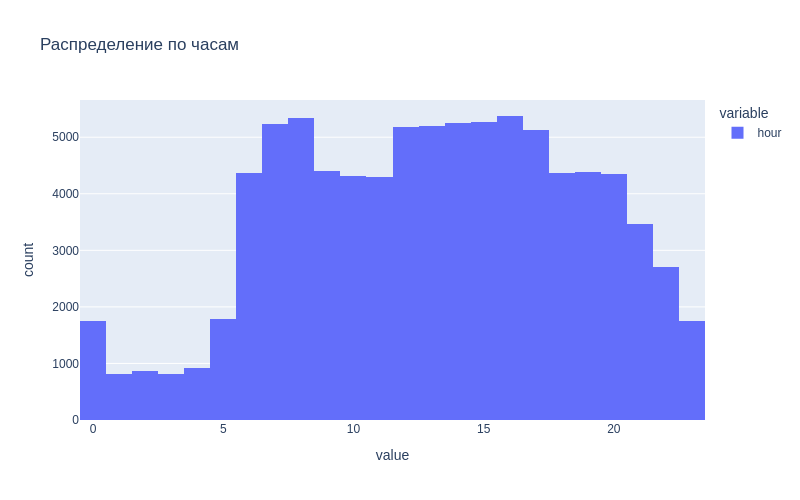

,user_id,track_id,timestamp,hour,track_genre,track_duration_sec,action,listen_time_sec,model_confidence,date_part
0,4117,1229,2025-01-01 00:03:23,0,rock,118,skip,45,0.324460,ночь
1,1448,1938,2025-01-01 00:04:14,0,electronic,256,listen,252,0.602017,ночь
2,4917,2163,2025-01-01 00:07:50,0,pop,199,skip,23,0.678229,ночь
3,1860,2361,2025-01-01 00:07:54,0,pop,121,listen,121,0.665973,ночь
4,1292,1470,2025-01-01 00:08:02,0,rock,136,skip,60,0.452052,ночь


In [34]:
### инжиниринг
h=500
w=800
df_logs['timestamp']=pd.to_datetime(df_logs['timestamp'])
df_logs['hour']=df_logs['timestamp'].dt.hour
fig_h=px.histogram(df_logs['hour'],title='Распределение по часам', width=w, height=h)
fig_h.show('png')
df_logs['date_part']=np.select([df_logs['hour'].between(6,11), df_logs['hour'].between(12,17),df_logs['hour'].between(18,23),df_logs['hour'].between(0,5)],['утро','день','вечер','ночь'])
df_logs.head()


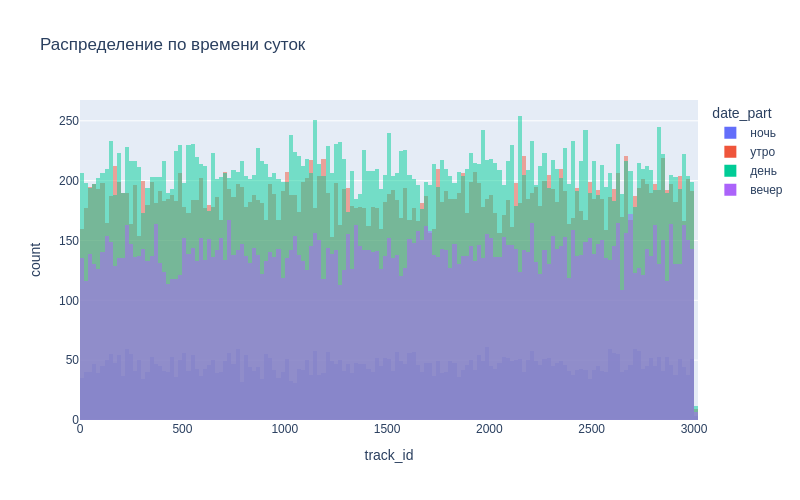

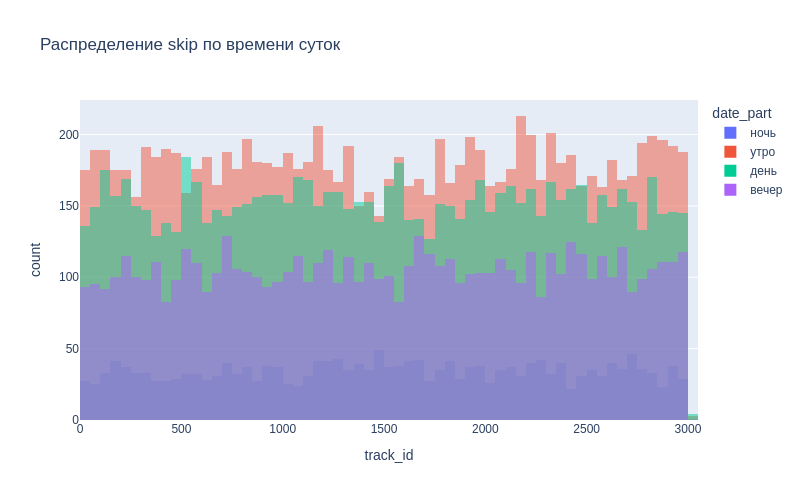

date_part,вечер,день,ночь,утро
action,,,,
listen,0.249305,0.376645,0.082548,0.291503
skip,0.222945,0.324380,0.072736,0.379939


In [35]:
hist_part=px.histogram(df_logs,x='track_id', color='date_part', barmode='overlay', title='Распределение по времени суток', height=h, width=w)
hist_part.show('png')
hist_sk=px.histogram(df_logs.query('action=="skip"'),x='track_id', color='date_part', barmode='overlay',title='Распределение skip по времени суток', height=h, width=w)
hist_sk.show('png')
pd.crosstab(df_logs['action'], df_logs['date_part'], normalize='index')

+ _скипают треки в основном утром_ 

In [36]:
###инжиниринг
df_morn=df_logs.query('date_part=="утро"').groupby('user_id')['action'].value_counts(normalize=True).unstack().reset_index()
# df_morn['morning_skip']=df_morn.get('skip',0)
ltv_full_df=ltv_df.merge(df_morn,how='left', on='user_id')
ltv_full_df.groupby('segment')['skip'].mean()

segment
1    0.747463
2    0.367287
Name: skip, dtype: float64

+ _процент скипа утром, у сегмента 1(менее активные) выше более чем в 2 раза, чем у сегмента 2(более активные)_